In [8]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

JRA_DIR = Path("/leonardo_scratch/fast/ICT26_ESP/ntilinin/INPUT/OMIP")
SPEEDY_DIR = Path("/leonardo_scratch/fast/ICT26_ESP/ntilinin/SPEEDY_access/access_forcing")

# 1990 only
RLDS_JRA_FILES = sorted(JRA_DIR.glob("rlds_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-5-0_gr_1990*.nc"))
RSDS_JRA_FILES = sorted(JRA_DIR.glob("rsds_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-5-0_gr_1990*.nc"))

RLDS_SPEEDY_FILES = [SPEEDY_DIR / "rlds_SPEEDY_1990.nc"]
RSDS_SPEEDY_FILES = [SPEEDY_DIR / "rsds_SPEEDY_1990.nc"]

# Open
RLDS_JRA = xr.open_mfdataset(RLDS_JRA_FILES, combine="by_coords", chunks={"time": 120},
                             data_vars="minimal", coords="minimal", compat="override")["rlds"]
RLDS_SPEEDY = xr.open_mfdataset(RLDS_SPEEDY_FILES, combine="by_coords", chunks={"time": 120},
                                data_vars="minimal", coords="minimal", compat="override")["rlds"]

RSDS_JRA = xr.open_mfdataset(RSDS_JRA_FILES, combine="by_coords", chunks={"time": 120},
                             data_vars="minimal", coords="minimal", compat="override")["rsds"]
RSDS_SPEEDY = xr.open_mfdataset(RSDS_SPEEDY_FILES, combine="by_coords", chunks={"time": 120},
                                data_vars="minimal", coords="minimal", compat="override")["rsds"]

print("RLDS JRA:", RLDS_JRA.shape, RLDS_JRA.time.values[0], "to", RLDS_JRA.time.values[-1])
print("RLDS SPEEDY:", RLDS_SPEEDY.shape, RLDS_SPEEDY.time.values[0], "to", RLDS_SPEEDY.time.values[-1])
print("RSDS JRA:", RSDS_JRA.shape, RSDS_JRA.time.values[0], "to", RSDS_JRA.time.values[-1])
print("RSDS SPEEDY:", RSDS_SPEEDY.shape, RSDS_SPEEDY.time.values[0], "to", RSDS_SPEEDY.time.values[-1])

RLDS JRA: (2920, 320, 640) 1990-01-01T01:30:00.000000000 to 1990-12-31T22:30:00.000000000
RLDS SPEEDY: (2920, 48, 96) 1990-01-01T01:30:00.000000000 to 1990-12-31T22:30:00.000000000
RSDS JRA: (2920, 320, 640) 1990-01-01T01:30:00.000000000 to 1990-12-31T22:30:00.000000000
RSDS SPEEDY: (2920, 48, 96) 1990-01-01T01:30:00.000000000 to 1990-12-31T22:30:00.000000000


In [3]:
# JRA -> SPEEDY grid
RLDS_JRA_S = RLDS_JRA.interp(lat=RLDS_SPEEDY.lat, lon=RLDS_SPEEDY.lon)
RSDS_JRA_S = RSDS_JRA.interp(lat=RSDS_SPEEDY.lat, lon=RSDS_SPEEDY.lon)

del RLDS_JRA, RSDS_JRA

In [4]:
RLDS_JRA_mean = RLDS_JRA_S.mean("time", skipna=True).compute()
RSDS_JRA_mean = RSDS_JRA_S.mean("time", skipna=True).compute()

In [5]:
RLDS_SPEEDY_mean = RLDS_SPEEDY.mean("time", skipna=True).compute()
RSDS_SPEEDY_mean = RSDS_SPEEDY.mean("time", skipna=True).compute()

In [6]:
def normalize_lon(da):
    return da.assign_coords(lon=((da.lon + 180) % 360) - 180).sortby("lon")

RLDS_JRA_mean = normalize_lon(RLDS_JRA_mean)
RSDS_JRA_mean = normalize_lon(RSDS_JRA_mean)

RLDS_SPEEDY_mean = normalize_lon(RLDS_SPEEDY_mean)
RSDS_SPEEDY_mean = normalize_lon(RSDS_SPEEDY_mean)

RLDS_diff=RLDS_SPEEDY_mean-RLDS_JRA_mean
RSDS_diff=RSDS_SPEEDY_mean-RSDS_JRA_mean

/scratch_local/ipykernel_1254908/2724413254.py:85: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Nimbus Sans.
  fig.savefig("../figures/diff_annual_mean_RLDS_1990.png",
/scratch_local/ipykernel_1254908/2724413254.py:85: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Nimbus Sans.
  fig.savefig("../figures/diff_annual_mean_RLDS_1990.png",
/leonardo/home/userexternal/ntilinin/.conda/envs/ocean/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Nimbus Sans.
  fig.canvas.print_figure(bytes_io, **kw)


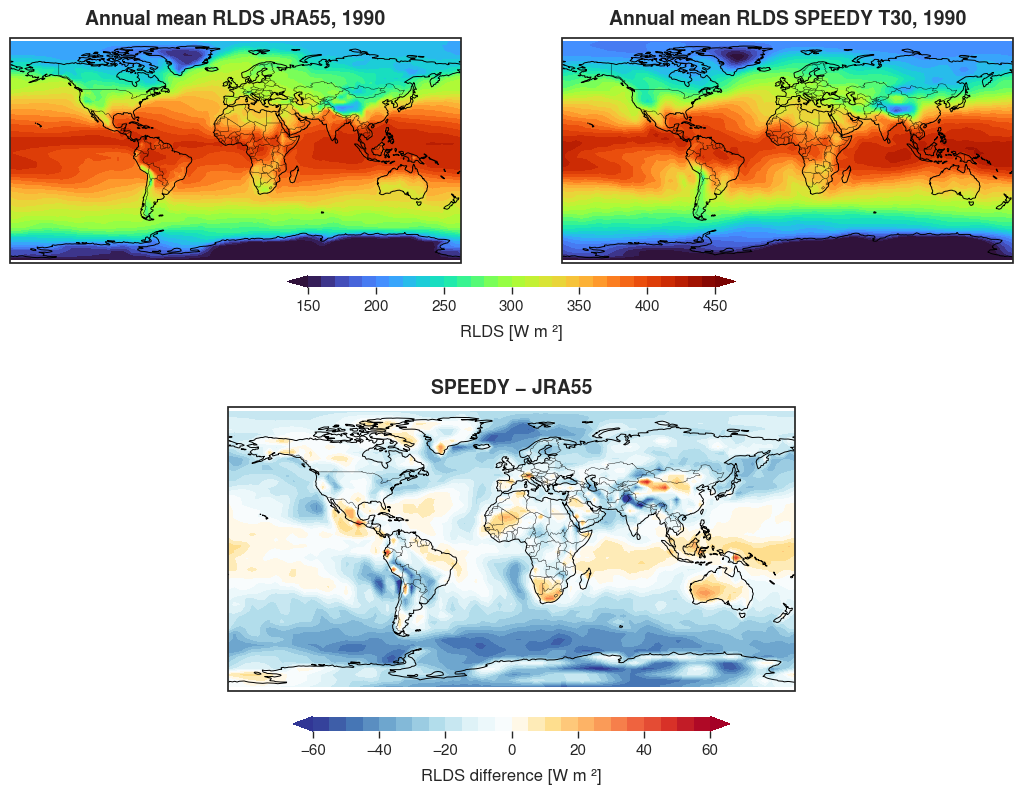

In [9]:
sns.set_theme(style="white")
plt.rcParams.update({"font.family": "Nimbus Sans"})

rlds_cmap = plt.get_cmap("turbo")

diff_cmap = LinearSegmentedColormap.from_list(
    "RldsBlueWhiteRed",
    ["#313695", "#4575b4", "#74add1", "#abd9e9", "#e0f3f8", "#ffffff",
     "#fee090", "#fdae61", "#f46d43", "#d73027", "#a50026"],
    N=256
)

rlds_levels = np.arange(150, 451, 10)
rlds_ticks = np.arange(150, 451, 50)

diff_levels = np.arange(-60, 65, 5)
diff_norm = mcolors.TwoSlopeNorm(vmin=-60, vcenter=0, vmax=60)
diff_ticks = np.arange(-60, 61, 20)

def make_cyclic(da):
    data, lon = add_cyclic_point(
        da.values, coord=da.lon.values, axis=da.get_axis_num("lon")
    )
    return data, lon

def setup_map(ax):
    ax.set_global()
    ax.coastlines(resolution="110m", linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

fig = plt.figure(figsize=(14, 9), facecolor="white")
gs = fig.add_gridspec(2, 6, height_ratios=[1, 1.3], hspace=0.42, wspace=0.12)

ax1 = fig.add_subplot(gs[0, 0:3], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0, 3:6], projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(gs[1, 0:6], projection=ccrs.PlateCarree())

# JRA55
data, lon = make_cyclic(RLDS_JRA_mean)
im1 = ax1.contourf(
    lon, RLDS_JRA_mean.lat, data, levels=rlds_levels,
    cmap=rlds_cmap, transform=ccrs.PlateCarree(), extend="both"
)
setup_map(ax1)
ax1.set_title("Annual mean RLDS JRA55, 1990",
              fontsize=14, fontweight="bold", pad=10)

# SPEEDY
data, lon = make_cyclic(RLDS_SPEEDY_mean)
im2 = ax2.contourf(
    lon, RLDS_SPEEDY_mean.lat, data, levels=rlds_levels,
    cmap=rlds_cmap, transform=ccrs.PlateCarree(), extend="both"
)
setup_map(ax2)
ax2.set_title("Annual mean RLDS SPEEDY T30, 1990",
              fontsize=14, fontweight="bold", pad=10)

# Difference
data, lon = make_cyclic(RLDS_diff)
im3 = ax3.contourf(
    lon, RLDS_diff.lat, data, levels=diff_levels,
    norm=diff_norm, cmap=diff_cmap,
    transform=ccrs.PlateCarree(), extend="both"
)
setup_map(ax3)
ax3.set_title("SPEEDY − JRA55", fontsize=14, fontweight="bold", pad=10)

# Colorbars
cbar1 = fig.colorbar(
    im1, ax=[ax1, ax2], orientation="horizontal",
    fraction=0.045, pad=0.05, aspect=40, ticks=rlds_ticks
)
cbar1.set_label("RLDS [W m⁻²]", fontsize=12, labelpad=8)
cbar1.ax.tick_params(labelsize=11, length=5, width=1)
cbar1.outline.set_visible(False)

cbar2 = fig.colorbar(
    im3, ax=ax3, orientation="horizontal",
    fraction=0.045, pad=0.08, aspect=30, ticks=diff_ticks
)
cbar2.set_label("RLDS difference [W m⁻²]", fontsize=12, labelpad=8)
cbar2.ax.tick_params(labelsize=11, length=5, width=1)
cbar2.outline.set_visible(False)

fig.savefig("../figures/diff_annual_mean_RLDS_1990.png",
            dpi=150, bbox_inches="tight")

plt.show()

In [ ]:
sns.set_theme(style="white")
plt.rcParams.update({"font.family": "Nimbus Sans"})

rsds_cmap = plt.get_cmap("turbo")

diff_cmap = LinearSegmentedColormap.from_list(
    "RsdsBlueWhiteRed",
    ["#313695", "#4575b4", "#74add1", "#abd9e9", "#e0f3f8", "#ffffff",
     "#fee090", "#fdae61", "#f46d43", "#d73027", "#a50026"],
    N=256
)

rsds_levels = np.arange(150, 451, 10)
rsds_ticks = np.arange(150, 451, 50)

diff_levels = np.arange(-60, 65, 5)
diff_norm = mcolors.TwoSlopeNorm(vmin=-60, vcenter=0, vmax=60)
diff_ticks = np.arange(-60, 61, 20)

def make_cyclic(da):
    data, lon = add_cyclic_point(
        da.values, coord=da.lon.values, axis=da.get_axis_num("lon")
    )
    return data, lon

def setup_map(ax):
    ax.set_global()
    ax.coastlines(resolution="110m", linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

fig = plt.figure(figsize=(14, 9), facecolor="white")
gs = fig.add_gridspec(2, 6, height_ratios=[1, 1.3], hspace=0.42, wspace=0.12)

ax1 = fig.add_subplot(gs[0, 0:3], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0, 3:6], projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(gs[1, 0:6], projection=ccrs.PlateCarree())

# JRA55
data, lon = make_cyclic(RSDS_JRA_mean)
im1 = ax1.contourf(
    lon, RSDS_JRA_mean.lat, data, levels=rsds_levels,
    cmap=rsds_cmap, transform=ccrs.PlateCarree(), extend="both"
)
setup_map(ax1)
ax1.set_title("Annual mean RSDS JRA55, 1990",
              fontsize=14, fontweight="bold", pad=10)

# SPEEDY
data, lon = make_cyclic(RSDS_SPEEDY_mean)
im2 = ax2.contourf(
    lon, RSDS_SPEEDY_mean.lat, data, levels=rlds_levels,
    cmap=rlds_cmap, transform=ccrs.PlateCarree(), extend="both"
)
setup_map(ax2)
ax2.set_title("Annual mean RSDS SPEEDY T30, 1990",
              fontsize=14, fontweight="bold", pad=10)

# Difference
data, lon = make_cyclic(RLDS_diff)
im3 = ax3.contourf(
    lon, RLDS_diff.lat, data, levels=diff_levels,
    norm=diff_norm, cmap=diff_cmap,
    transform=ccrs.PlateCarree(), extend="both"
)
setup_map(ax3)
ax3.set_title("SPEEDY − JRA55", fontsize=14, fontweight="bold", pad=10)

# Colorbars
cbar1 = fig.colorbar(
    im1, ax=[ax1, ax2], orientation="horizontal",
    fraction=0.045, pad=0.05, aspect=40, ticks=rlds_ticks
)
cbar1.set_label("RSDS [W m⁻²]", fontsize=12, labelpad=8)
cbar1.ax.tick_params(labelsize=11, length=5, width=1)
cbar1.outline.set_visible(False)

cbar2 = fig.colorbar(
    im3, ax=ax3, orientation="horizontal",
    fraction=0.045, pad=0.08, aspect=30, ticks=diff_ticks
)
cbar2.set_label("RSDS difference [W m⁻²]", fontsize=12, labelpad=8)
cbar2.ax.tick_params(labelsize=11, length=5, width=1)
cbar2.outline.set_visible(False)

fig.savefig("../figures/diff_annual_mean_RSDS_1990.png",
            dpi=150, bbox_inches="tight")

plt.show()